## Samelson model of the Berkley Jet
The Bickley jet

In [1]:
# Base imports and path setting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax
import jax.numpy as jnp
import diffrax as dfx
from time import time

import sys
import os
from os.path import dirname
cwd = os.getcwd()
sys.path.append(dirname(cwd))


In [2]:
# Relative import and macroscopic configs
from src.flows import samelson_flow, trajectory_plot, stream_plot
from src.lyapunov import *

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(seed=42069)
FIG_PATH = dirname(cwd) + "/figs/"

In [3]:
# Flow selection and parameters
rhs = samelson_flow
pars = {
    "A0": 1.064,
    "C": 0.25,
    "L": 2,
    "h": 0.1,
    "wf": 0.56,
}

# Integration options
dt = 0.001
N_iters = 2e5
timesteps = np.linspace(0, dt*N_iters, 500000)

steps = 20
burns = 0.2

solver = dfx.Kvaerno5()
stepsc = dfx.PIDController(rtol=1e-8, atol=1e-8)
term = dfx.ODETerm(rhs)
saveat = dfx.SaveAt(ts=timesteps)

# Graph boundaries and grids
X_space = np.linspace(-2*np.pi, 2*np.pi, 400)
Y_space = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(X_space, Y_space)
U, V = rhs(t=0, z=(X, Y), params=pars)

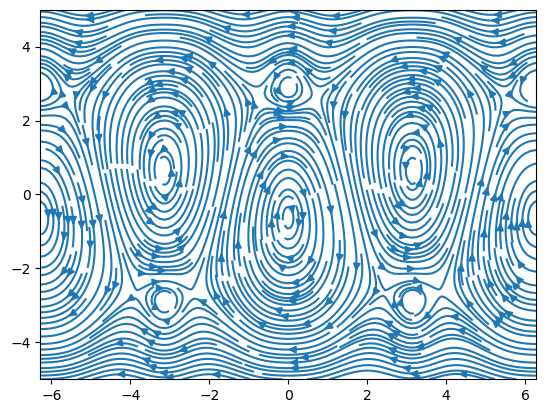

In [4]:
# Animation of the flow
starting_lines = np.array([i.flatten() for i in np.meshgrid(
                            np.linspace(-2*np.pi, 2*np.pi, 200),
                            np.linspace(-5, 5, 200),
                            indexing="ij"
                           )]).T

dens=3

fig, ax = plt.subplots()
stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)

def animate(ti):
    ax.clear()
    ax.grid(True)
    U, V = rhs(t=ti, z=(X, Y), params=pars)
    stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)
    print(ti)
    return stream

#anim = animation.FuncAnimation(fig, animate, frames=np.linspace(0, 2*np.pi/pars.get("wf", 1), 100), interval=50, blit=False, repeat=False)
#anim.save( FIG_PATH + '/samelson.gif', writer='imagemagick', fps=30)
# plt.show()


In [4]:
# First experiment 1: lyapunov computation interval variation for different initial conditions
# Setup and calculations
pars_list = pars.copy()
pars_list.update({"h": 0})

shapes = (5, 10)
step_range = jnp.linspace(1, 21, shapes[1])
STEP, X0, = jnp.meshgrid(step_range, jnp.linspace(-jnp.pi, jnp.pi, shapes[0]) - 0.3)
z0_range = jnp.array([jnp.concat(X0), jnp.zeros(len(jnp.concat(X0)))]).T

var_compute = make_batch_fast_lyapunov(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
var_lyap_ext = jax.jit(
    jax.vmap(var_compute, in_axes=(0, None, {"A0": None, "C": None, "L": None, "h": None, "wf": None}, 0))
)

var_step_mlyap = jnp.sort(var_lyap_ext(z0_range, 0, pars_list, jnp.concat(STEP)*dt)).reshape(*shapes, 2)[:, :, -1]


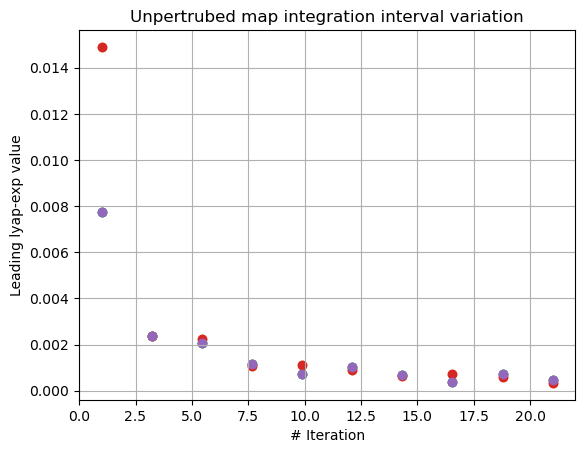

In [5]:
for i in range(var_step_mlyap.shape[0]):
    plt.scatter(step_range, var_step_mlyap[i, :])
plt.grid(True)
plt.xlabel("# Iteration"); plt.ylabel("Leading lyap-exp value"); plt.title("Unpertrubed map integration interval variation")
plt.savefig(FIG_PATH + "Interval_variation_z0.png", dpi=500)
plt.show()

In [4]:
# First experiment 2: lyapunov computation interval variation
# Setup and calculations
z0 = jnp.array([np.pi/2, 0])
pars_list = pars.copy()
pars_list.update({"h": 0})

step_range = jnp.linspace(1, 30, 50)

var_compute = make_batch_fast_lyapunov(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
var_lyap_ext = jax.jit(
    jax.vmap(var_compute, in_axes=(None, None, {"A0": None, "C": None, "L": None, "h": None, "wf": None}, 0))
)

var_step_mlyap = jnp.sort(var_lyap_ext(z0, 0, pars_list, step_range*dt))[:, -1]


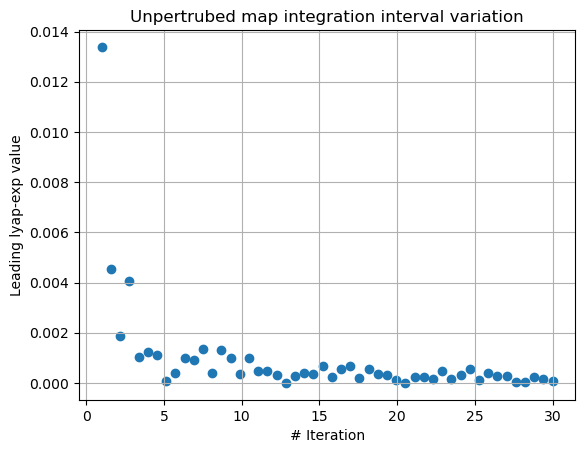

In [5]:
plt.scatter(step_range, var_step_mlyap)
plt.grid(True)
plt.xlabel("# Iteration"); plt.ylabel("Leading lyap-exp value"); plt.title("Unpertrubed map integration interval variation")
plt.savefig(FIG_PATH + "Interval_variation.png", dpi=500)
plt.show()

In [ ]:
# First experiment 3: trajectory check

### Results comment
After ~ 20 steps, the Lyapunov exponents stabilize, so we take that as the number of integration steps to be done before recomputing QR decomposition.

In [5]:
# Third experiment: parameters variation
# Setup and calculations
z0 = jnp.array([np.pi/2, 0])
pars_list = pars.copy()
shapes = (10, 10)
H, WF = jnp.meshgrid(jnp.logspace(-2, 1, shapes[0]), jnp.logspace(-2, 1, shapes[1]))

pars_list.update({"h": jnp.concat(H)})
pars_list.update({"wf": jnp.concat(WF)})

var_par_compute = make_batch_fast_lyapunov(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
var_par_lyap = jax.jit(
    jax.vmap(var_par_compute, in_axes=(None, None, {"A0": None, "C": None, "L": None, "h": 0, "wf": 0}, None))
)

var_cum_lyaps = jnp.sort(var_par_lyap(z0, 0, pars_list, 20*dt))[:, -1]


Lyapunov exponents extimate for parameters h = 0.0100, wf = 0.0100: 0.00047
Lyapunov exponents extimate for parameters h = 0.0215, wf = 0.0100: 0.00027
Lyapunov exponents extimate for parameters h = 0.0464, wf = 0.0100: 0.00057
Lyapunov exponents extimate for parameters h = 0.1000, wf = 0.0100: 0.00132
Lyapunov exponents extimate for parameters h = 0.2154, wf = 0.0100: 0.00409
Lyapunov exponents extimate for parameters h = 0.4642, wf = 0.0100: 0.00503
Lyapunov exponents extimate for parameters h = 1.0000, wf = 0.0100: 0.00389
Lyapunov exponents extimate for parameters h = 2.1544, wf = 0.0100: 0.00830
Lyapunov exponents extimate for parameters h = 4.6416, wf = 0.0100: 0.00559
Lyapunov exponents extimate for parameters h = 10.0000, wf = 0.0100: 0.00687
Lyapunov exponents extimate for parameters h = 0.0100, wf = 0.0215: 0.00053
Lyapunov exponents extimate for parameters h = 0.0215, wf = 0.0215: 0.00000
Lyapunov exponents extimate for parameters h = 0.0464, wf = 0.0215: 0.00078
Lyapunov ex

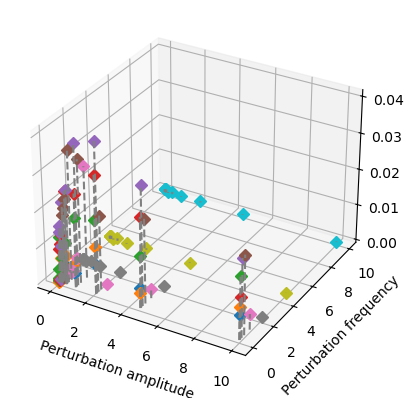

'pert_pars = pars.copy()\n\npert_pars.update({"h": 0.5})\nU_full, V_full = rhs(t=np.pi/(pars.get("wf")), z=(X, Y), params=pert_pars)\nplt.streamplot(X, Y, U_full, V_full, density=3, color=np.sqrt(U_full**2 + V_full**2), cmap=\'plasma\')\nplt.grid()\nplt.savefig(FIG_PATH + "Sam_Perturbed_flow.png", dpi=1500)\nplt.show()\n'

In [ ]:
# Plots
for cum, h, wf in zip(var_cum_lyaps, jnp.concat(H), jnp.concat(WF)):
    print(f"Lyapunov exponents extimate for parameters h = {h:.4f}, wf = {wf:.4f}: {cum:.5f}")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for cum, h, wf in zip(var_cum_lyaps.reshape(10,10), H, WF):
    markerline, stemlines, baseline = ax.stem(
        h, wf, cum, linefmt='grey', markerfmt='D')
    markerline.set_markerfacecolor('none')
    stemlines.set(linestyle="--")
    baseline.remove()

plt.xlabel("Perturbation amplitude")
plt.ylabel("Perturbation frequency")
plt.grid(True)
plt.savefig(FIG_PATH + "Pars_variation_gross.png", dpi=1500)
plt.show()

# Perturbated flow
#plt.streamplot(X, Y, U , V, density=3)

"""pert_pars = pars.copy()

pert_pars.update({"h": 0.5})
U_full, V_full = rhs(t=np.pi/(pars.get("wf")), z=(X, Y), params=pert_pars)
plt.streamplot(X, Y, U_full, V_full, density=3, color=np.sqrt(U_full**2 + V_full**2), cmap='plasma')
plt.grid()
plt.savefig(FIG_PATH + "Sam_Perturbed_flow.png", dpi=1500)
plt.show()
"""

### Osservazioni
Vediamo che al crescere di $w_f$ sopra $~ 0.46$ il sistema ha esponente di lyapunov minore.
Il mLCE tende a decrescere per $h > 3$

In [4]:
# Third experiment: parameters variation
# Setup and calculations
z0 = jnp.array([np.pi/2, 0])
pars_list = pars.copy()
shapes = (10, 10)
H, WF = jnp.meshgrid(jnp.logspace(jnp.log(0.05), 0, shapes[0]), jnp.logspace(jnp.log(0.05), jnp.log10(0.6), shapes[1]))

pars_list.update({"h": jnp.concat(H)})
pars_list.update({"wf": jnp.concat(WF)})

var_par_compute = make_batch_fast_lyapunov(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
var_par_lyap = jax.jit(
    jax.vmap(var_par_compute, in_axes=(None, None, {"A0": None, "C": None, "L": None, "h": 0, "wf": 0}, None))
)

var_cum_lyaps = jnp.sort(var_par_lyap(z0, 0, pars_list, 20*dt))[:, -1]


Lyapunov exponents extimate for parameters h = 0.0010, wf = 0.0010: 0.00060
Lyapunov exponents extimate for parameters h = 0.0022, wf = 0.0010: 0.00036
Lyapunov exponents extimate for parameters h = 0.0047, wf = 0.0010: 0.00023
Lyapunov exponents extimate for parameters h = 0.0101, wf = 0.0010: 0.00081
Lyapunov exponents extimate for parameters h = 0.0217, wf = 0.0010: 0.00001
Lyapunov exponents extimate for parameters h = 0.0466, wf = 0.0010: 0.00023
Lyapunov exponents extimate for parameters h = 0.1003, wf = 0.0010: 0.00220
Lyapunov exponents extimate for parameters h = 0.2159, wf = 0.0010: 0.00106
Lyapunov exponents extimate for parameters h = 0.4647, wf = 0.0010: 0.00202
Lyapunov exponents extimate for parameters h = 1.0000, wf = 0.0010: 0.00094
Lyapunov exponents extimate for parameters h = 0.0010, wf = 0.0021: 0.00079
Lyapunov exponents extimate for parameters h = 0.0022, wf = 0.0021: 0.00073
Lyapunov exponents extimate for parameters h = 0.0047, wf = 0.0021: 0.00046
Lyapunov exp

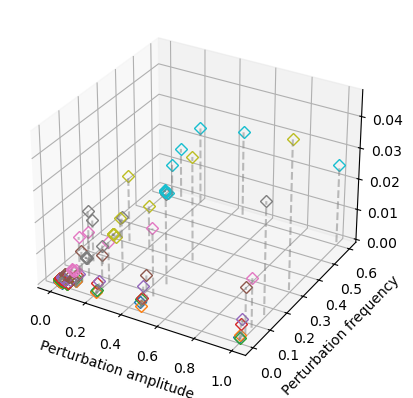

In [6]:
# Plots
for cum, h, wf in zip(var_cum_lyaps, jnp.concat(H), jnp.concat(WF)):
    print(f"Lyapunov exponents extimate for parameters h = {h:.4f}, wf = {wf:.4f}: {cum:.5f}")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for cum, h, wf in zip(var_cum_lyaps.reshape(10,10), H, WF):
    markerline, stemlines, baseline = ax.stem(
        h, wf, cum, linefmt='grey', markerfmt='D')
    markerline.set_markerfacecolor('none')
    stemlines.set(linestyle="--", alpha=0.5)
    baseline.remove()

plt.xlabel("Perturbation amplitude")
plt.ylabel("Perturbation frequency")
plt.grid(True)
plt.savefig(FIG_PATH + "Pars_variation_fine.png", dpi=1500)
plt.show()

# Perturbated flow
#plt.streamplot(X, Y, U , V, density=3)

### Results
Maximum mLCE obtained at $w_f = 0.56$
For the stream to not be completely destroyed, we chose $h = 0.1$

In [4]:
# Second experiment 1: lyapunov exponents for 100 random initial condition

# Define random ranges
rand_flurry = jnp.array([rng.random(100)*4*np.pi - 2*np.pi, rng.random(100)*8 - 4]).T
t0 = 0.0

# Build mappable function
rand_compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns))
batched_lyap = jax.jit(
    jax.vmap(rand_compute, in_axes=(0, None, None, None))
)

# Execute
rand_trajects, rand_cum_lyaps = batched_lyap(rand_flurry, t0, pars, steps*dt)

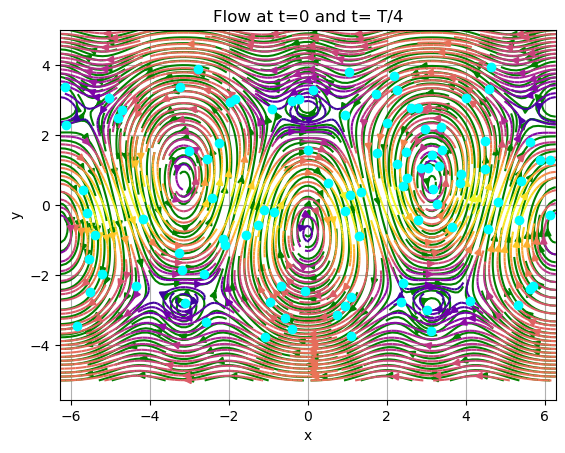

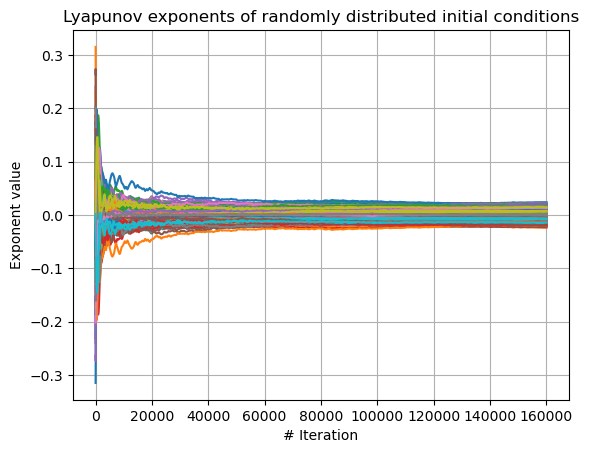

Lyapunov exponents extimate (averaged over random trajectories): [ 0.00683308 -0.00683308] +- [0.00753874 0.00753874]


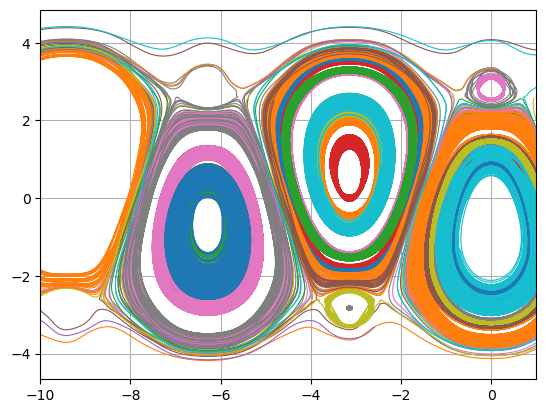

In [5]:
# Flow at different times with flurry
plt.streamplot(X, Y, U , V, density=3, color="green",)
U_flur, V_flur = rhs(t=np.pi/(pars.get("wf")), z=(X, Y), params=pars)
plt.streamplot(X, Y, U_flur, V_flur, density=3, color=np.sqrt(U_flur**2 + V_flur**2), cmap='plasma',)
plt.scatter(*rand_flurry.T, c="cyan", zorder=10)
plt.grid()
plt.xlabel("x"); plt.ylabel("y"); plt.title("Flow at t=0 and t= T/4")
plt.savefig(FIG_PATH + "Flurry_flow.png", dpi=1500)
plt.show()

# Plot and results
for cum in rand_cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.xlabel("# Iteration"); plt.ylabel("Exponent value"); plt.title("Lyapunov exponents of randomly distributed initial conditions")
plt.savefig(FIG_PATH + "Rand_lyaps.png")
plt.show()
lyap_ext = rand_cum_lyaps.mean(axis=0)[-1, :]
lyap_std = rand_cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponents extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")

# Trajectories
rand_trajects_trasp = np.transpose(rand_trajects, axes=(0, -1, -2))
#with plt.style.context('Solarize_Light2'):
plt.xlim(left=-10)
for traj in rand_trajects_trasp:
    plt.plot(*traj, linewidth=0.8)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_trajects.png", dpi=1500)
plt.show()


In [4]:
# Second experiment 2: non-random condition

# Define points
flurry = jnp.concat([jnp.array([jnp.linspace(-jnp.pi, jnp.pi, 30), jnp.zeros(30)]).T,
                     jnp.array([jnp.linspace(-jnp.pi/2, jnp.pi/2, 10), jnp.full(10, 2.75)]).T,
                     jnp.array([jnp.linspace(-jnp.pi*3/2, -jnp.pi/2, 10), jnp.full(10, -2.75)]).T,
                                ])
t0_batch = jnp.zeros(len(flurry))

# Build mappable function
flurry_compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns))
batched_lyap = jax.jit(
    jax.vmap(flurry_compute, in_axes=(0, 0, None, None))
)

# Execute
flurry_trajects, flurry_cum_lyaps = batched_lyap(flurry, t0_batch, pars, steps*dt)

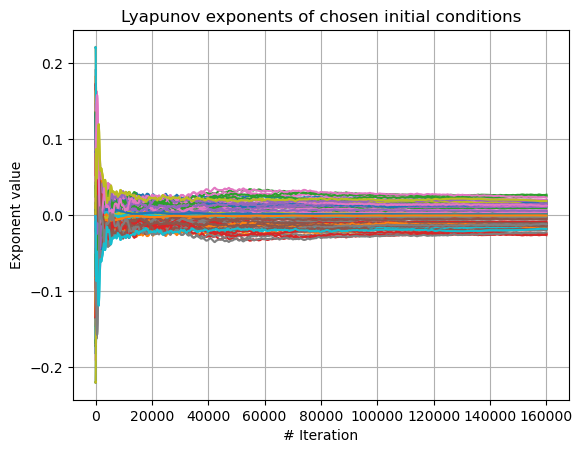

Lyapunov exponents extimate (averaged over trajectories): [ 0.0090885 -0.0090885] +- [0.00817665 0.00817665]


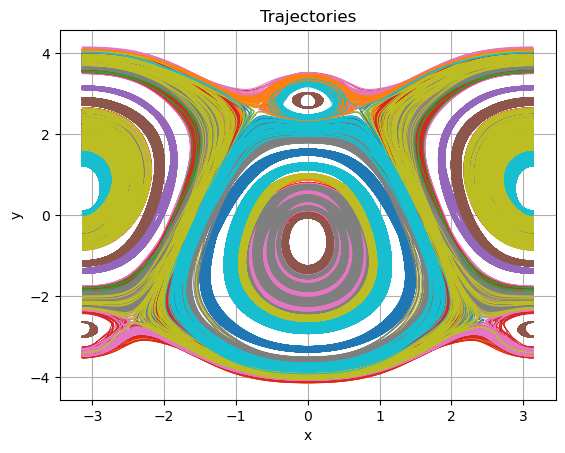

In [5]:
# Plot and results
for cum in flurry_cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.xlabel("# Iteration"); plt.ylabel("Exponent value"); plt.title("Lyapunov exponents of chosen initial conditions")
plt.savefig(FIG_PATH + "Flurry_lyaps.png")
plt.show()
lyap_ext = flurry_cum_lyaps.mean(axis=0)[-1, :]
lyap_std = flurry_cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponents extimate (averaged over trajectories): {lyap_ext} +- {lyap_std}")

# Trajectories
flurry_trajects_trasp = np.transpose(flurry_trajects, axes=(0, -1, -2))
#with plt.style.context('Solarize_Light2'):
fig, ax = plt.subplots()
for traj in flurry_trajects_trasp:
    plot_wrapped(*traj, ax=ax, linewidth=0.75)
plt.grid(True)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Trajectories")
plt.savefig(FIG_PATH + "Flurry_trajects.png", dpi=1500)
plt.show()


### Interpretazione del risultato
La stima dei coefficienti di Lyapunov è entro 2 sigma dallo zero, fatto che potrebbe essere dato dalla quantità relativamente alta di punti inizializzati all'interno delle strutture cicloidi del flusso, che rimangono intrappolati in traiettorie stabili.
Dalla figura infatti se ne vedono alcune che rimangono all'interno delle cicloidi, sia grandi che piccole, oppure ancora nei flussi sopra e sotto l'area centrale nell'asse y, anche se queste vediamo che possono rientrare nella serpentina.
In conclusione, stimare come media su condizioni random potrebbe non portare a risultati significativi, in quanto vi sono zone della mappa dal comportamento qualitativamente diverso, e non è detto che queste comunichino con le altre per l'ampiezza di perturbazione considerata.

### Interpretazioni del risultato
Vediamo che le prime cinque traiettorie graficate (secondo il cycling di default di matplotlib.pyplot.plot, dalla prima blu alla viola) seguono il flusso perturbato che è simile a quello analizzato in precedenza. 
Le utlime sei, invece, mostrano un andamento più erratico, con le ultime che saltano da una cicloide all'altra "tagliando" il flusso imperturbato, o addirittura procedendo nel verso contrario del flusso.
Andando poi a graficare il flusso a metà periodo della perturbazione (ampiezza h = 1) si nota la comparsa di un flusso centrale in senso opposto e la distruzione delle cicloidi più piccole.